In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

import matplotlib.pyplot as plt

In [3]:
def dj_oracle(n, balanced=True):

    oracle = QuantumCircuit(n + 1)

    if balanced:
        for qubit in range(n):
            oracle.cx(qubit, n)

    return oracle

In [4]:
def deutsch_jozsa_circuit(n, balanced=True):

    qc = QuantumCircuit(n + 1, n)

    qc.x(n)

    qc.h(range(n + 1))

    oracle = dj_oracle(n, balanced)
    qc.compose(oracle, inplace=True)

    qc.h(range(n))

    qc.measure(range(n), range(n))

    return qc

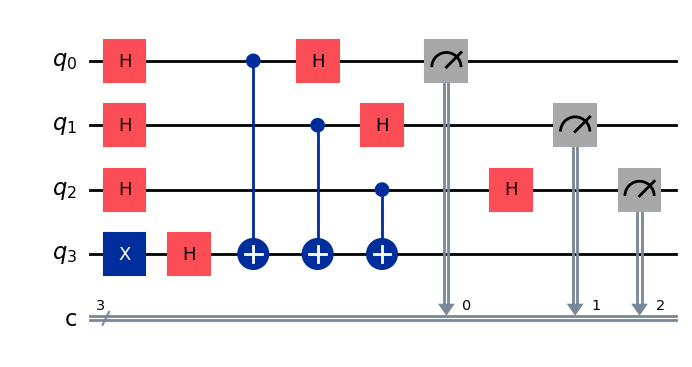

In [5]:
n = 3

qc = deutsch_jozsa_circuit(n, balanced=True)

qc.draw("mpl")

In [6]:
simulator = AerSimulator()

job = simulator.run(qc, shots=1024)

result = job.result()

counts_local = result.get_counts()

print(counts_local)

{'111': 1024}


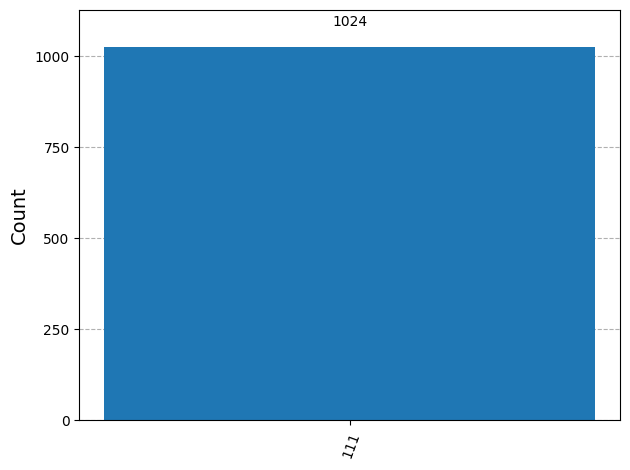

In [7]:
from IPython.display import display

fig = plot_histogram(counts_local)
display(fig)

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token="O6mKHX7tFUU4l6oKcMnLWL1aMEf-OrfsTk4eapxofFnG"
)

print("Connected successfully!")

qiskit_runtime_service._discover_account:WARNING:2026-05-25 14:46:29,114: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-25 14:46:34,761: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Connected successfully!


In [9]:
backend = service.least_busy(
    operational=True,
    simulator=False
)

print(backend)

qiskit_runtime_service.backends:WARNING:2026-05-25 14:46:36,419: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-25 14:46:40,446: Using instance: open-instance, plan: open


<IBMBackend('ibm_kingston')>


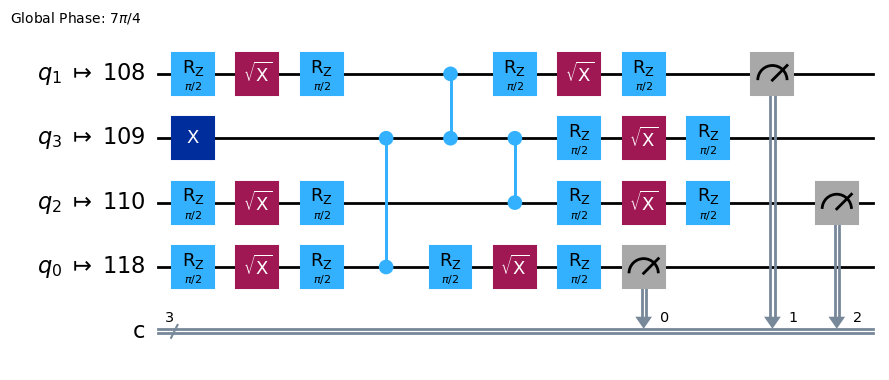

In [10]:
from qiskit import transpile

transpiled_qc = transpile(
    qc,
    backend=backend,
    optimization_level=1
)

transpiled_qc.draw("mpl")

In [11]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(backend)

job = sampler.run([transpiled_qc], shots=1024)

print("Job submitted!")

Job submitted!


In [13]:
result = job.result()

counts_ibm = result[0].data.c.get_counts()

print(counts_ibm)

{'111': 960, '011': 24, '110': 20, '101': 19, '001': 1}


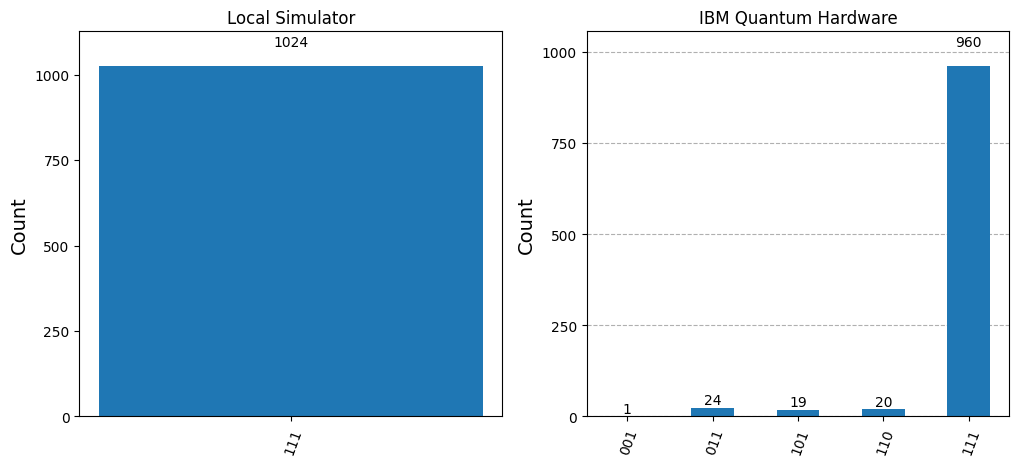

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

plot_histogram(counts_local, ax=ax[0])
ax[0].set_title("Local Simulator")

plot_histogram(counts_ibm, ax=ax[1])
ax[1].set_title("IBM Quantum Hardware")

plt.show()